In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import LabelEncoder
# from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
help(np.cov)#to get the documentation
#Tab for available functions nad shift+tab for entire documentation
np.cov?

Help on _ArrayFunctionDispatcher in module numpy:

cov(m, y=None, rowvar=True, bias=False, ddof=None, fweights=None, aweights=None, *, dtype=None)
    Estimate a covariance matrix, given data and weights.

    Covariance indicates the level to which two variables vary together.
    If we examine N-dimensional samples, :math:`X = [x_1, x_2, ... x_N]^T`,
    then the covariance matrix element :math:`C_{ij}` is the covariance of
    :math:`x_i` and :math:`x_j`. The element :math:`C_{ii}` is the variance
    of :math:`x_i`.

    See the notes for an outline of the algorithm.

    Parameters
    ----------
    m : array_like
        A 1-D or 2-D array containing multiple variables and observations.
        Each row of `m` represents a variable, and each column a single
        observation of all those variables. Also see `rowvar` below.
    y : array_like, optional
        An additional set of variables and observations. `y` has the same form
        as that of `m`.
    rowvar : bool, optio

Signature:      
np.cov(
    m,
    y=None,
    rowvar=True,
    bias=False,
    ddof=None,
    fweights=None,
    aweights=None,
    *,
    dtype=None,
)
Call signature:  np.cov(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function cov at 0x0000025B4382ECA0>
File:            c:\programdata\anaconda3\lib\site-packages\numpy\lib\function_base.py
Docstring:      
Estimate a covariance matrix, given data and weights.

Covariance indicates the level to which two variables vary together.
If we examine N-dimensional samples, :math:`X = [x_1, x_2, ... x_N]^T`,
then the covariance matrix element :math:`C_{ij}` is the covariance of
:math:`x_i` and :math:`x_j`. The element :math:`C_{ii}` is the variance
of :math:`x_i`.

See the notes for an outline of the algorithm.

Parameters
----------
m : array_like
    A 1-D or 2-D array containing multiple variables and observations.
    Each row of `m` represents a variable, and each column a single
    observation of all t

### On the Carseats Data

In [4]:
from ISLP import load_data
carseats = load_data('Carseats')
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [5]:
# Encoding the categorical Variables
carseats['ShelveLoc_enc'] = LabelEncoder().fit_transform(carseats['ShelveLoc'])
carseats['Urban_enc'] = LabelEncoder().fit_transform(carseats['Urban'])
carseats['US_enc'] = LabelEncoder().fit_transform(carseats['US'])

In [7]:
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,ShelveLoc_enc,Urban_enc,US_enc
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,0,1,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1,1,1
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,2,1,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,2,1,1
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0,1,0


In [8]:
carseats.drop(['ShelveLoc', 'Urban', 'US'], axis = 1, inplace=True)
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_enc,Urban_enc,US_enc
0,9.50,138,73,11,276,120,42,17,0,1,1
1,11.22,111,48,16,260,83,65,10,1,1,1
2,10.06,113,35,10,269,80,59,12,2,1,1
3,7.40,117,100,4,466,97,55,14,2,1,1
4,4.15,141,64,3,340,128,38,13,0,1,0


In [9]:
len(carseats)

400

In [12]:
carseats.shape

(400, 11)

In [10]:
train = carseats.loc[:299]
test = carseats.loc[300:]

In [13]:
print(f'Train : {train.shape}'); print(f'Test: {test.shape}')

Train : (300, 11)
Test: (100, 11)


In [14]:
y_train = train['Sales']
x_train = train.drop(['Sales'], axis = 1)
y_test = test['Sales']
x_test = test.drop(['Sales'], axis = 1)

In [15]:
# Since using all the features at each step, so it is pure bagging (max_features).
b = RandomForestRegressor(max_features = x_train.shape[1], random_state=0)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
grid = GridSearchCV(b,
                    param_grid={'n_estimators': [100,200,400,500,700,800,900,1000]},
                    scoring='neg_mean_squared_error',
                    cv = kf,
                    n_jobs = -1)
grid.fit(x_train, y_train)

,estimator,RandomForestR...andom_state=0)
,param_grid,"{'n_estimators': [100, 200, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,800


In [16]:
grid.best_params_

{'n_estimators': 800}

In [17]:
# Bagged Model

bag = RandomForestRegressor(max_features= x_train.shape[1], n_estimators=800, random_state=0)
bag.fit(x_train, y_train)

,n_estimators,800
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred_train = bag.predict(x_train)
train_mse = mean_squared_error(y_train, y_pred_train)
train_r2_score = r2_score(y_train, y_pred_train)

print('Bagged Model')
print(f'Train MSE : {train_mse}')
print(f'Train R2 score : {train_r2_score}')

Bagged Model
Train MSE : 0.33340969335729537
Train R2 score : 0.9583847937893094


In [20]:
# Linear Regression

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred_reg_train = model.predict(x_train)
train_mse_reg = mean_squared_error(y_train, y_pred_reg_train)
train_r2_score_reg = r2_score(y_train, y_pred_reg_train)

print('Linear Regression')
print(f'Train MSE : {train_mse_reg}')
print(f'Train R2 score : {train_r2_score_reg}')

Linear Regression
Train MSE : 3.196646626205739
Train R2 score : 0.6010040764180753


In [22]:
# Regression Tree
from sklearn.tree import DecisionTreeRegressor
rt = DecisionTreeRegressor(random_state=0)
rt.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [23]:
y_pred_regTree_train = rt.predict(x_train)
train_mse_regTree = mean_squared_error(y_train, y_pred_regTree_train)
train_r2_score_regTree = r2_score(y_train, y_pred_regTree_train)

print('Regression Tree')
print(f'Train MSE : {train_mse_regTree}')
print(f'Train R2 score : {train_r2_score_regTree}') # overfiting , high variance

Regression Tree
Train MSE : 0.0
Train R2 score : 1.0


### Variable Importance

In [24]:
# Feature Importance based on average decrease in Node impurity

# On the fitted model 'bag'
# Feature Importance based on avg decrease in node impurity (reg: train mse/ classification: gini index)
# (every split results in decease in node impurity,
# for each feature total decrease in node impurity is avg over all the bagged trees)

bag.feature_importances_

array([0.11587371, 0.06413501, 0.07670637, 0.04737146, 0.28948433,
       0.09345437, 0.02653617, 0.27506802, 0.00617226, 0.00519831])

In [28]:
bag.feature_names_in_

array(['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age',
       'Education', 'ShelveLoc_enc', 'Urban_enc', 'US_enc'], dtype=object)

In [29]:
feature_imp = pd.Series(data = bag.feature_importances_, index = x_train.columns)
feature_imp.sort_values(ascending=False)

Price            0.289484
ShelveLoc_enc    0.275068
CompPrice        0.115874
Age              0.093454
Advertising      0.076706
Income           0.064135
Population       0.047371
Education        0.026536
Urban_enc        0.006172
US_enc           0.005198
dtype: float64

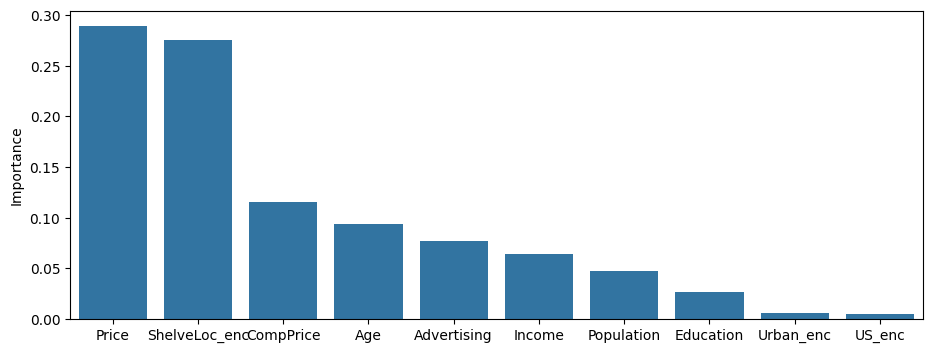

In [31]:
import seaborn as sns
plt.figure(figsize=(11,4))
sns.barplot(feature_imp.sort_values(ascending=False))
plt.ylabel('Importance')
plt.show()

In [32]:
# Feature Importance based on Train MSE.

# When u randomly permute/shuffle the features, how the train mse changes
# if some important feature gets permuted, then will cause the model to perform poorly and will lead to increase in train mse
# if some less relevant feature gets permuted, then will not a significant effect on the model, train mse will not increase
# drop in model performance  = measure of importance (more drop in performance, increase in train mse, more important feature)

from sklearn.inspection import permutation_importance

result = permutation_importance(bag,
                                x_train, y_train,
                                scoring = 'neg_mean_squared_error',
                                n_repeats = 10,
                                random_state = 0)
result.importances_mean

array([1.54743973, 0.5278583 , 0.7605178 , 0.2752409 , 5.57119879,
       0.9310536 , 0.1188068 , 5.06117267, 0.02775796, 0.02106063])

In [34]:
df = pd.DataFrame({'Features': x_train.columns, 'Feature_Importance':result.importances_mean})
df.head()

,Features,Feature_Importance
0,CompPrice,1.547440
1,Income,0.527858
2,Advertising,0.760518
3,Population,0.275241
4,Price,5.571199


In [35]:
df = df.sort_values(ascending=False, by = 'Feature_Importance') # sorting based on the feature_importance

In [36]:
df

,Features,Feature_Importance
4,Price,5.571199
7,ShelveLoc_enc,5.061173
0,CompPrice,1.547440
5,Age,0.931054
2,Advertising,0.760518
1,Income,0.527858
3,Population,0.275241
6,Education,0.118807
8,Urban_enc,0.027758
9,US_enc,0.021061


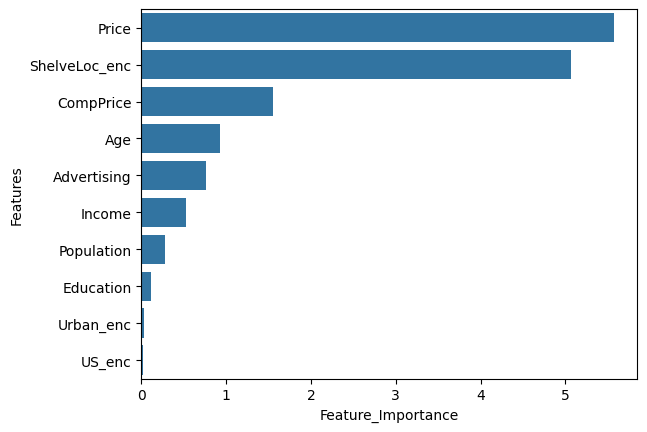

In [37]:
sns.barplot(x = df['Feature_Importance'], y = df['Features'])
plt.show()

In [38]:
# Test MSE and Test R2 for bagged model

y_pred_test = bag.predict(x_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_r2_score = r2_score(y_test, y_pred_test)

print('Bagged Model')
print(f'Test MSE : {test_mse}')
print(f'Test R2 score : {test_r2_score}')

Bagged Model
Test MSE : 2.396888365859387
Test R2 score : 0.683543627107364


In [39]:
# Test MSE and Test R2 for Linear Regression model

y_pred_test_reg = model.predict(x_test)
test_mse_reg = mean_squared_error(y_test, y_pred_test_reg)
test_r2_score_reg = r2_score(y_test, y_pred_test_reg)

print('Linear Regression')
print(f'Test MSE : {test_mse_reg}')
print(f'Test R2 score : {test_r2_score_reg}')

Linear Regression
Test MSE : 4.1591737273881195
Test R2 score : 0.45087261853862903


In [40]:
# Test MSE and Test R2 for Regression Tree model

y_pred_test_regTree = rt.predict(x_test)
test_mse_regTree =  mean_squared_error(y_test, y_pred_test_regTree)
test_r2_score_regTree = r2_score(y_test, y_pred_test_regTree)

print('Regression Tree')
print(f'Test MSE : {test_mse_regTree}')
print(f'Test R2 score : {test_r2_score_regTree}')

Regression Tree
Test MSE : 5.969302999999999
Test R2 score : 0.21188487416274193


In [41]:
# Bagged model performs best among all three models.

In [42]:
# OOB MSE

oob_bag = RandomForestRegressor(n_estimators=800, max_features=x_train.shape[1], random_state=0, oob_score=True)
oob_bag.fit(x_train, y_train)

,n_estimators,800
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [45]:
y_pred_oob = oob_bag.oob_prediction_
oob_mse = mean_squared_error(y_train, y_pred_oob)
oob_r2 = oob_bag.oob_score_

print(f'OOB MSE : {oob_mse}')
print(f'OOB R2 score : {oob_r2}')

OOB MSE : 2.4480726643720616
OOB R2 score : 0.6944388517300166


### On the Breast Cancer Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
breast_cancer = pd.DataFrame(data = data.data, columns = data.feature_names)
breast_cancer['Target'] = data.target
breast_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
y = breast_cancer['Target']
x = breast_cancer.drop(['Target'], axis = 1)

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=0)

In [6]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((455, 30), (455,), (114, 30), (114,))

In [7]:
# Using all the features at each step, since we are concerned with bagging (max_features).

In [8]:
b = RandomForestClassifier(max_features = x_train.shape[1], random_state=0)
kf = KFold(n_splits=5, shuffle = True, random_state=0)
grid = GridSearchCV(b,
                    param_grid = {'n_estimators':[100,600,700,1000,1100,1200,1500,1700,2000]},
                    cv = kf,
                    scoring='accuracy',
                    n_jobs = -1)
grid.fit(x_train, y_train)

,estimator,RandomForestC...andom_state=0)
,param_grid,"{'n_estimators': [100, 600, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,1500


In [9]:
grid.best_params_

{'n_estimators': 1500}

In [10]:
bag = RandomForestClassifier(max_features = x_train.shape[1], random_state = 0, n_estimators = 1500)
bag.fit(x_train, y_train)

,n_estimators,1500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,30
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
from sklearn.metrics import accuracy_score, f1_score
y_pred_train = bag.predict(x_train)
y_pred_test = bag.predict(x_test)
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
f1_train = f1_score(y_train, y_pred_train)
f1_test = f1_score(y_test, y_pred_test)

print(f'Train F1 score : {f1_train}')
print(f'Test F1 Score: {f1_test}')
print(f'Train Acc : {acc_train}')
print(f'Test Acc : {acc_test}')

Train F1 score : 1.0
Test F1 Score: 0.9777777777777777
Train Acc : 1.0
Test Acc : 0.9736842105263158


In [12]:
# Feature Importance - Node impurity method - based on gini index

df = pd.DataFrame({'Features':x_train.columns, 'Feature Importance':bag.feature_importances_})
df = df.sort_values(ascending = False, by = 'Feature Importance')
df.head()

,Features,Feature Importance
27,worst concave points,0.291975
22,worst perimeter,0.275329
7,mean concave points,0.158139
23,worst area,0.059928
20,worst radius,0.051548


[]

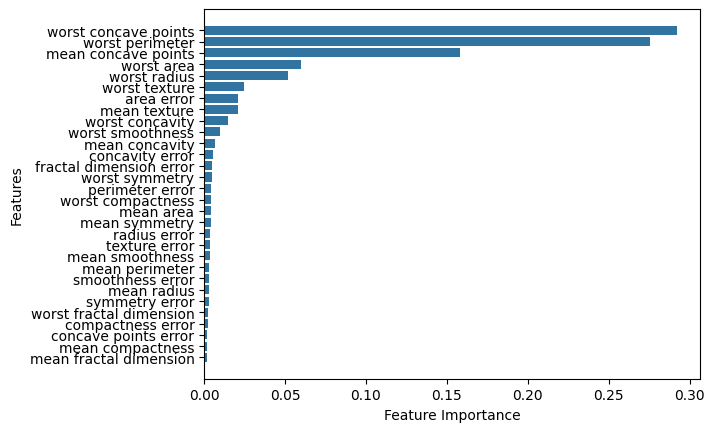

In [13]:
import seaborn as sns
sns.barplot(x = df['Feature Importance'], y = df['Features'])
plt.plot()

In [14]:
# Permutation method

from sklearn.inspection import permutation_importance
result = permutation_importance(bag,
                                x_train, y_train,
                                n_repeats = 10,
                                scoring = 'accuracy',
                                random_state = 0
                                )

In [15]:
df1 = pd.DataFrame({'Features': x_train.columns, 'Feature Imp': result.importances_mean})
df1 = df1.sort_values(ascending = False, by = 'Feature Imp')
df1.head()

,Features,Feature Imp
27,worst concave points,0.023956
22,worst perimeter,0.009670
21,worst texture,0.004615
13,area error,0.003956
14,smoothness error,0.002198


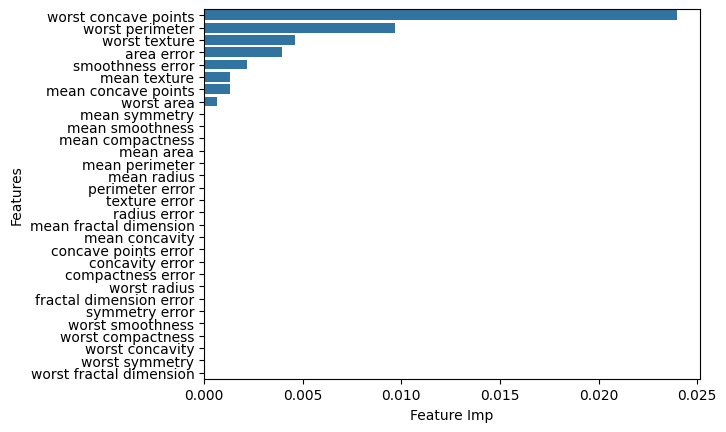

In [16]:
sns.barplot(x = df1['Feature Imp'], y = df1['Features'])
plt.show()

In [17]:
# OOB

oob_bag = RandomForestClassifier(n_estimators=1500, max_features = x_train.shape[1], random_state=0, oob_score = True)
oob_bag.fit(x_train, y_train)

,n_estimators,1500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,30
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [18]:
# oob Accuracy
print(f'OOB Accuracy: {oob_bag.oob_score_}')

OOB Accuracy: 0.9516483516483516


In [19]:
oob_bag.oob_decision_function_.shape # each row is a one training sample, and each column is a class

(455, 2)

In [30]:
oob_bag.oob_decision_function_ # OOB predicted probabilities → one row per sample, one column per class.
# oob_decision_function_[i,k] = estimated probability that training sample i belongs to class k,
# computed only from trees that didn’t include sample i in their bootstrap subset.

array([[0.        , 1.        ],
       [0.01277372, 0.98722628],
       [0.47197107, 0.52802893],
       [0.        , 1.        ],
       [0.03684211, 0.96315789],
       [0.        , 1.        ],
       [0.03272727, 0.96727273],
       [0.        , 1.        ],
       [0.82198953, 0.17801047],
       [0.04133858, 0.95866142],
       [1.        , 0.        ],
       [0.39338235, 0.60661765],
       [0.30474453, 0.69525547],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.00168634, 0.99831366],
       [0.        , 1.        ],
       [0.18130841, 0.81869159],
       [0.20855615, 0.79144385],
       [0.        , 1.        ],
       [0.20576923, 0.79423077],
       [0.56343284, 0.43656716],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.00896057, 0.99103943],
       [0.00766284, 0.99233716],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.

In [32]:
prob = oob_bag.oob_decision_function_ 
oob_y_pred = np.argmax(prob, axis = 1) # axis = 0, going down over the samples and axis = 1, going right over the classes

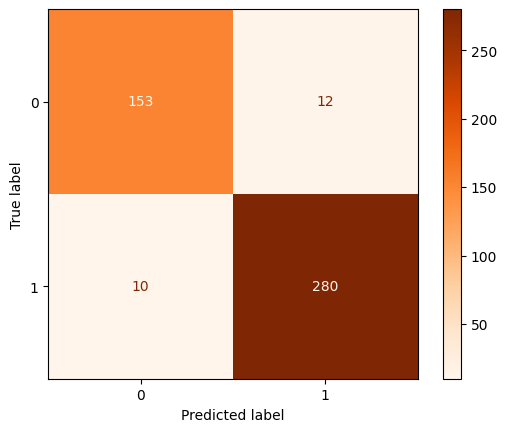

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true= y_train, y_pred = oob_y_pred)
ConfusionMatrixDisplay(cm).plot(cmap = 'Oranges')
plt.show()

In [36]:
cm

array([[153,  12],
       [ 10, 280]])

In [37]:
misclf_rate = (cm.sum() - np.trace(cm))/cm.sum()
print(f'Misclassification Rate : ', misclf_rate)

Misclassification Rate :  0.04835164835164835
